In [2]:
import pandas as pd

In [3]:
column_names = [
    "buying",
    "maint",
    "doors",
    "persons",
    "lug_boot",
    "safety",
    "class"
 ]

car_data = pd.read_csv("car.csv", names=column_names)

print("The First 5 rows of the dataset:")
print(car_data.head())

The First 5 rows of the dataset:
  buying  maint doors persons lug_boot safety  class
0  vhigh  vhigh     2       2    small    low  unacc
1  vhigh  vhigh     2       2    small    med  unacc
2  vhigh  vhigh     2       2    small   high  unacc
3  vhigh  vhigh     2       2      med    low  unacc
4  vhigh  vhigh     2       2      med    med  unacc


In [4]:
print("The Dataset info:")
car_data.info()

print("\nThe Number of cars in each class:")
print(car_data["class"].value_counts())

The Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB

The Number of cars in each class:
class
unacc    1210
acc       384
good       69
vgood      65
Name: count, dtype: int64


In [5]:
encoded_data = pd.get_dummies(car_data, drop_first=False)

print("The Encoded version of the data:")
print(encoded_data.head())

The Encoded version of the data:
   buying_high  buying_low  buying_med  buying_vhigh  maint_high  maint_low  \
0        False       False       False          True       False      False   
1        False       False       False          True       False      False   
2        False       False       False          True       False      False   
3        False       False       False          True       False      False   
4        False       False       False          True       False      False   

   maint_med  maint_vhigh  doors_2  doors_3  ...  lug_boot_big  lug_boot_med  \
0      False         True     True    False  ...         False         False   
1      False         True     True    False  ...         False         False   
2      False         True     True    False  ...         False         False   
3      False         True     True    False  ...         False          True   
4      False         True     True    False  ...         False          True   

   lug_boot

In [6]:
x = pd.get_dummies(car_data.drop("class", axis=1))
y = car_data["class"]

print("The Shape of x:", x.shape)
print("The Shape of y:", y.shape)

The Shape of x: (1728, 21)
The Shape of y: (1728,)


In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("The Training data shape:", x_train.shape)
print("The Testing data shape:", x_test.shape)

print("\nClass distribution in full data (%):")
print(y.value_counts(normalize=True).round(3) * 100)

print("\nClass distribution in y_train (%):")
print(y_train.value_counts(normalize=True).round(3) * 100)

print("\nClass distribution in y_test (%):")
print(y_test.value_counts(normalize=True).round(3) * 100)

The Training data shape: (1382, 21)
The Testing data shape: (346, 21)

Class distribution in full data (%):
class
unacc    70.0
acc      22.2
good      4.0
vgood     3.8
Name: proportion, dtype: float64

Class distribution in y_train (%):
class
unacc    70.0
acc      22.2
good      4.0
vgood     3.8
Name: proportion, dtype: float64

Class distribution in y_test (%):
class
unacc    69.9
acc      22.3
good      4.0
vgood     3.8
Name: proportion, dtype: float64


In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

decision_tree_model = DecisionTreeClassifier()
decision_tree_model.fit(x_train, y_train)

decision_tree_predictions = decision_tree_model.predict(x_test)
decision_tree_accuracy = accuracy_score(y_test, decision_tree_predictions)

print("The Decision Tree Accuracy:", decision_tree_accuracy)

The Decision Tree Accuracy: 0.976878612716763


In [9]:
from sklearn.metrics import classification_report

print("The Classification Report:")
print(classification_report(y_test, decision_tree_predictions))

The Classification Report:
              precision    recall  f1-score   support

         acc       0.99      0.91      0.95        77
        good       0.88      1.00      0.93        14
       unacc       0.98      1.00      0.99       242
       vgood       1.00      1.00      1.00        13

    accuracy                           0.98       346
   macro avg       0.96      0.98      0.97       346
weighted avg       0.98      0.98      0.98       346



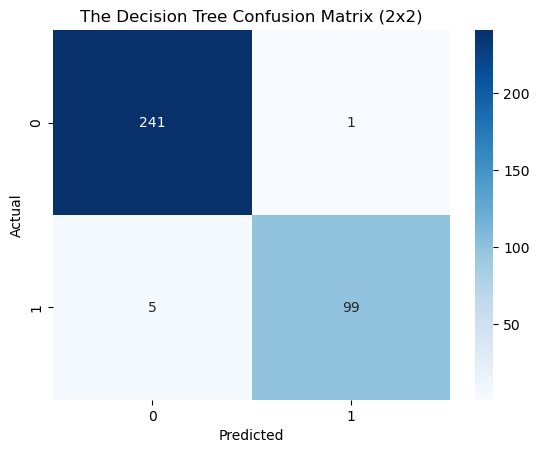

In [10]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 2x2 confusion matrix via one-vs-rest mapping (unacc vs others)
y_test_binary = (y_test != "unacc").astype(int)
decision_tree_binary = (decision_tree_predictions != "unacc").astype(int)

decision_tree_cm = confusion_matrix(y_test_binary, decision_tree_binary)

sns.heatmap(decision_tree_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("The Decision Tree Confusion Matrix (2x2)")
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

logistic_model = LogisticRegression(max_iter=2000, class_weight="balanced")
tree_model = DecisionTreeClassifier(random_state=42, class_weight="balanced")
forest_model = RandomForestClassifier(
    n_estimators=200, random_state=42, class_weight="balanced"
 )
svm_model = SVC(kernel="rbf", random_state=42, class_weight="balanced")

logistic_model.fit(x_train, y_train)
tree_model.fit(x_train, y_train)
forest_model.fit(x_train, y_train)
svm_model.fit(x_train, y_train)

logistic_predictions = logistic_model.predict(x_test)
logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_balanced_accuracy = balanced_accuracy_score(y_test, logistic_predictions)
logistic_f1_macro = f1_score(y_test, logistic_predictions, average="macro")

print("The Logistic Regression Accuracy:", logistic_accuracy)
print("The Logistic Regression Balanced Accuracy:", logistic_balanced_accuracy)
print("The Logistic Regression F1 Macro:", logistic_f1_macro)

The Logistic Regression Accuracy: 0.8872832369942196
The Logistic Regression Balanced Accuracy: 0.93314639905549
The Logistic Regression F1 Macro: 0.8315341901630355


In [12]:
tree_predictions = tree_model.predict(x_test)
tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_balanced_accuracy = balanced_accuracy_score(y_test, tree_predictions)
tree_f1_macro = f1_score(y_test, tree_predictions, average="macro")

print("The Decision Tree Accuracy:", tree_accuracy)
print("The Decision Tree Balanced Accuracy:", tree_balanced_accuracy)
print("The Decision Tree F1 Macro:", tree_f1_macro)

The Decision Tree Accuracy: 0.953757225433526
The Decision Tree Balanced Accuracy: 0.8957179184451912
The Decision Tree F1 Macro: 0.9123343220565442


In [13]:
forest_predictions = forest_model.predict(x_test)
forest_accuracy = accuracy_score(y_test, forest_predictions)
forest_balanced_accuracy = balanced_accuracy_score(y_test, forest_predictions)
forest_f1_macro = f1_score(y_test, forest_predictions, average="macro")

print("The Random Forest Accuracy:", forest_accuracy)
print("The Random Forest Balanced Accuracy:", forest_balanced_accuracy)
print("The Random Forest F1 Macro:", forest_f1_macro)

The Random Forest Accuracy: 0.9710982658959537
The Random Forest Balanced Accuracy: 0.9457928435201164
The Random Forest F1 Macro: 0.9605828683101411


In [14]:
svm_predictions = svm_model.predict(x_test)
svm_accuracy = accuracy_score(y_test, svm_predictions)
svm_balanced_accuracy = balanced_accuracy_score(y_test, svm_predictions)
svm_f1_macro = f1_score(y_test, svm_predictions, average="macro")

print("The SVM Accuracy:", svm_accuracy)
print("The SVM Balanced Accuracy:", svm_balanced_accuracy)
print("The SVM F1 Macro:", svm_f1_macro)

The SVM Accuracy: 0.953757225433526
The SVM Balanced Accuracy: 0.9812573789846517
The SVM F1 Macro: 0.9595740509276278


In [15]:
model_results = {
    "Logistic Regression": logistic_accuracy,
    "Decision Tree": tree_accuracy,
    "Random Forest": forest_accuracy,
    "SVM": svm_accuracy
}

imbalance_results = pd.DataFrame(
    {
        "accuracy": [logistic_accuracy, tree_accuracy, forest_accuracy, svm_accuracy],
        "balanced_accuracy": [
            logistic_balanced_accuracy,
            tree_balanced_accuracy,
            forest_balanced_accuracy,
            svm_balanced_accuracy
        ],
        "f1_macro": [
            logistic_f1_macro,
            tree_f1_macro,
            forest_f1_macro,
            svm_f1_macro
        ]
    },
    index=["Logistic Regression", "Decision Tree", "Random Forest", "SVM"]
)

print("The Model Accuracy results:")
print(model_results)

print("\nImbalance-focused metrics:")
print(imbalance_results.round(4))

The Model Accuracy results:
{'Logistic Regression': 0.8872832369942196, 'Decision Tree': 0.953757225433526, 'Random Forest': 0.9710982658959537, 'SVM': 0.953757225433526}

Imbalance-focused metrics:
                     accuracy  balanced_accuracy  f1_macro
Logistic Regression    0.8873             0.9331    0.8315
Decision Tree          0.9538             0.8957    0.9123
Random Forest          0.9711             0.9458    0.9606
SVM                    0.9538             0.9813    0.9596


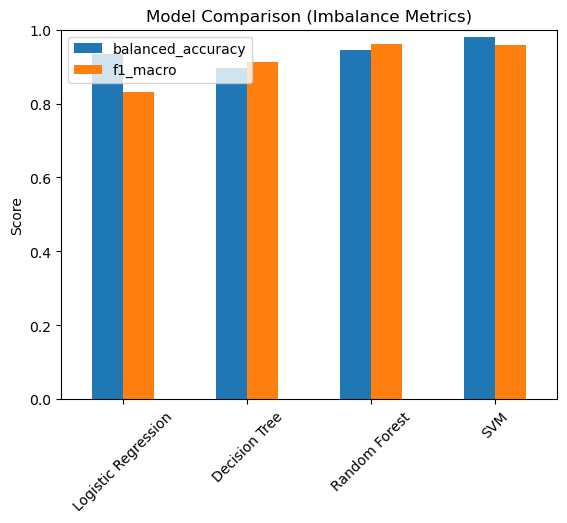

In [16]:
imbalance_results[["balanced_accuracy", "f1_macro"]].plot(kind="bar")
plt.xticks(rotation=45)
plt.ylabel("Score")
plt.title("Model Comparison (Imbalance Metrics)")
plt.ylim(0, 1)
plt.show()

Per-class recall:
       Logistic Regression  Decision Tree  Random Forest    SVM
unacc               0.8884         0.9835         0.9835  0.938
acc                 0.8442         0.8961         0.9481  0.987
good                1.0000         0.8571         0.9286  1.000
vgood               1.0000         0.8462         0.9231  1.000

Per-class F1-score:
       Logistic Regression  Decision Tree  Random Forest     SVM
unacc               0.9409         0.9794         0.9835  0.9680
acc                 0.7738         0.8961         0.9359  0.9048
good                0.8235         0.8571         0.9630  0.9655
vgood               0.7879         0.9167         0.9600  1.0000


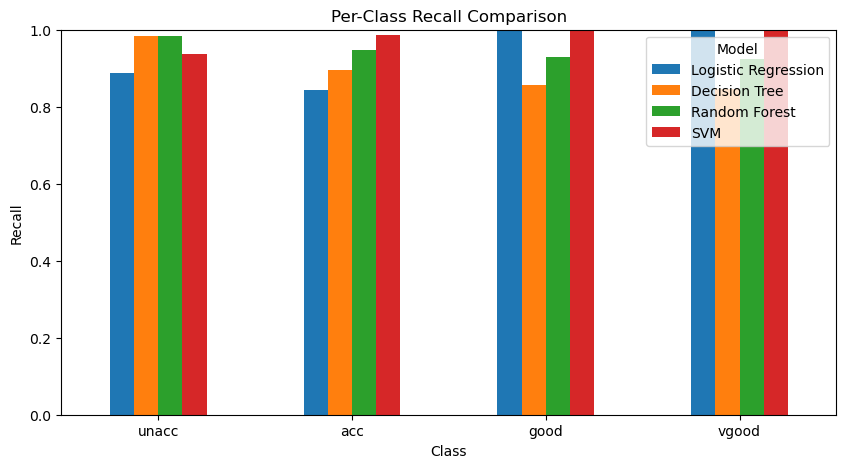

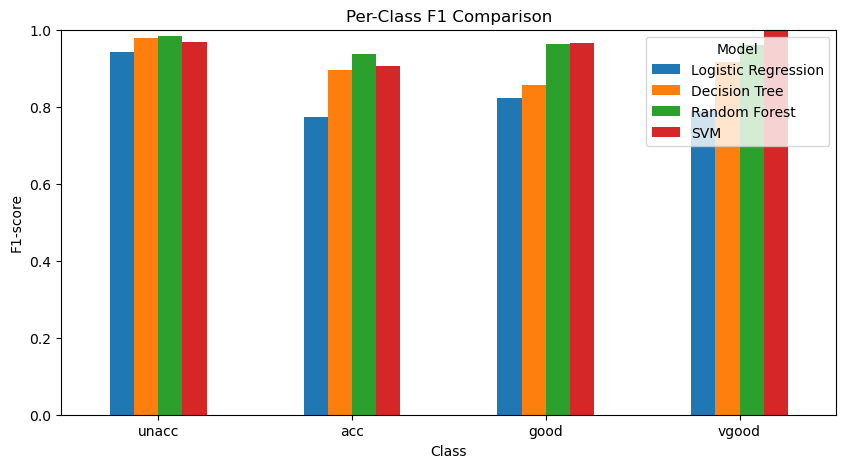

In [30]:
from sklearn.metrics import classification_report


all_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": tree_predictions,
    "Random Forest": forest_predictions,
    "SVM": svm_predictions
}

class_order = list(y.value_counts().index)

per_class_recall = pd.DataFrame(index=class_order)
per_class_f1 = pd.DataFrame(index=class_order)

for model_name, pred_values in all_predictions.items():
    report = classification_report(
        y_test, pred_values, output_dict=True, zero_division=0
    )
    per_class_recall[model_name] = [report[class_name]["recall"] for class_name in class_order]
    per_class_f1[model_name] = [report[class_name]["f1-score"] for class_name in class_order]

print("Per-class recall:")
print(per_class_recall.round(4))

print("\nPer-class F1-score:")
print(per_class_f1.round(4))

per_class_recall.plot(kind="bar", figsize=(10, 5))
plt.title("Per-Class Recall Comparison")
plt.xlabel("Class")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()

per_class_f1.plot(kind="bar", figsize=(10, 5))
plt.title("Per-Class F1 Comparison")
plt.xlabel("Class")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()

In [18]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(forest_model, x, y, cv=5)

print("The Cross validation accuracy:", cv_scores.mean())

The Cross validation accuracy: 0.7333249560191002


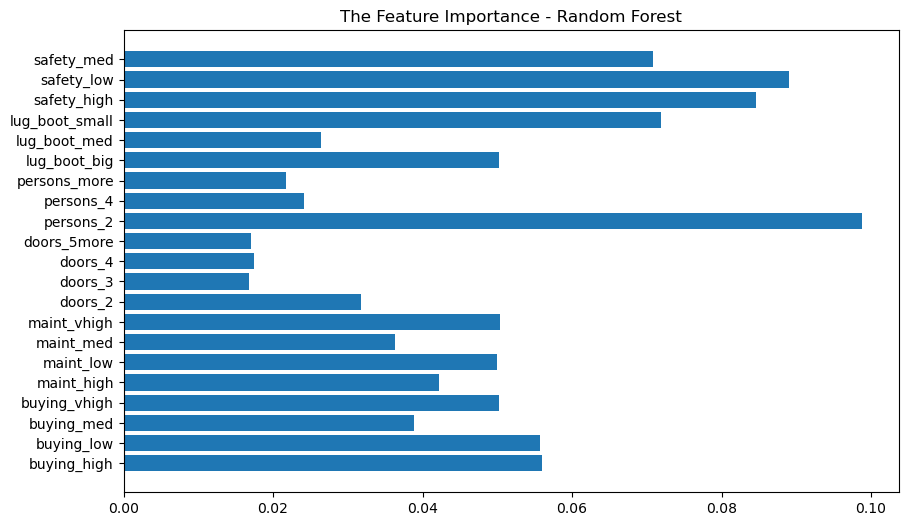

In [19]:
feature_importance_values = forest_model.feature_importances_
feature_names = x.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance_values)
plt.title("The Feature Importance - Random Forest")
plt.show()

In [20]:
from sklearn.metrics import accuracy_score

all_models = {
    "Logistic Regression": logistic_model,
    "Decision Tree": tree_model,
    "Random Forest": forest_model,
    "SVM": svm_model
}

final_results = {}

for model_name, current_model in all_models.items():
    current_predictions = current_model.predict(x_test)
    current_accuracy = accuracy_score(y_test, current_predictions)
    final_results[model_name] = current_accuracy

final_results

{'Logistic Regression': 0.8872832369942196,
 'Decision Tree': 0.953757225433526,
 'Random Forest': 0.9710982658959537,
 'SVM': 0.953757225433526}

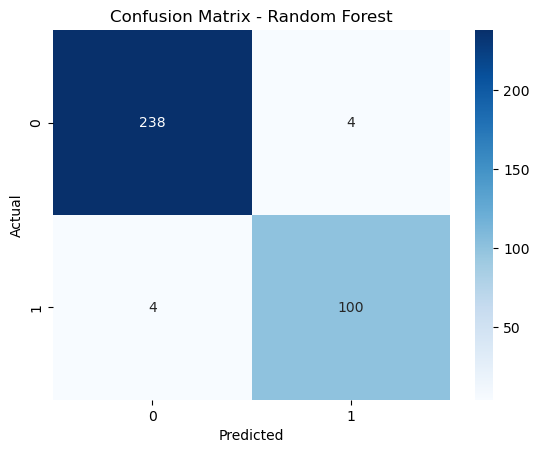

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

best_model = forest_model
best_model_predictions = best_model.predict(x_test)

y_test_binary = (y_test != "unacc").astype(int)
best_model_binary = (best_model_predictions != "unacc").astype(int)

best_model_cm = confusion_matrix(y_test_binary, best_model_binary)

sns.heatmap(best_model_cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

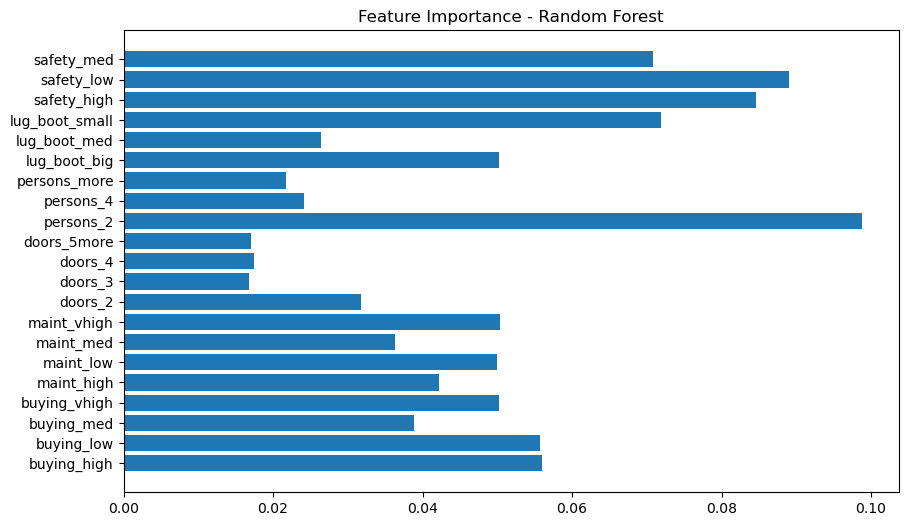

In [22]:
feature_importance_values = forest_model.feature_importances_
feature_names = x.columns

plt.figure(figsize=(10, 6))
plt.barh(feature_names, feature_importance_values)
plt.title("Feature Importance - Random Forest")
plt.show()

In [23]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(forest_model, x, y, cv=5)
print("The 5-Fold CV Accuracy:", cv_scores.mean())

The 5-Fold CV Accuracy: 0.7333249560191002


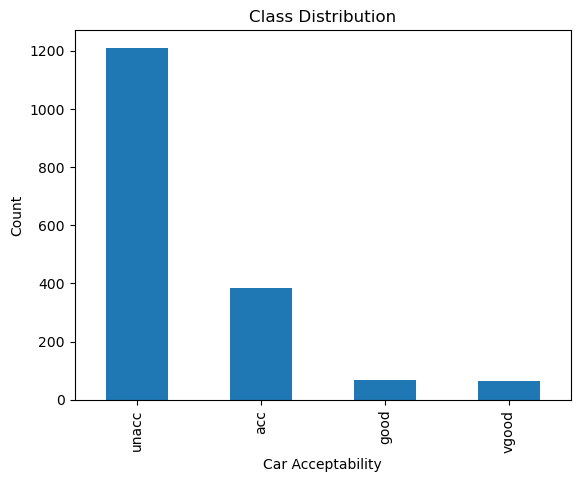

In [24]:
import matplotlib.pyplot as plt

car_data["class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Car Acceptability")
plt.ylabel("Count")
plt.show()